# 06 · Polarization & intensity — the soft-probability story

"Did the average move?" (notebook 02) is different from "did the conversation get
more **polarized**?" Two debates can share a mean of zero — one calm and neutral,
one split 50/50 between strong pro and strong anti.

Using the class probabilities we look at the **distribution** of per-item stance
`s = (p_pro − p_anti)` renormalized over on-topic mass (−1…+1), plus model
**entropy** (ambivalence) and a **bimodality** measure over time.

In [1]:
import sys; sys.path.append(".")        # so config / analysis_utils import on Deepnote too
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import config as C
import analysis_utils as A
A.apply_style()
pd.set_option("display.width", 120)

In [2]:
items = A.load_stance_items(drop_offtopic=True)   # item-level, on-topic only
items["s"] = A.net_stance_soft(items)             # -1 (anti) .. +1 (pro)
items["entropy"] = A.entropy(items)
items["period"] = A.time_bucket(items.et_date, "monthly")
items[["subreddit","stance_pred","s","entropy"]].head()

,subreddit,stance_pred,s,entropy
0,astoria,anti,-0.882710,0.537479
16,astoria,pro,0.951321,0.200214
17,astoria,pro,0.960139,0.186200
45,astoria,anti,-0.787230,0.490980
48,astoria,pro,0.190279,1.005122


### Distribution of stance by quarter — ridgeline

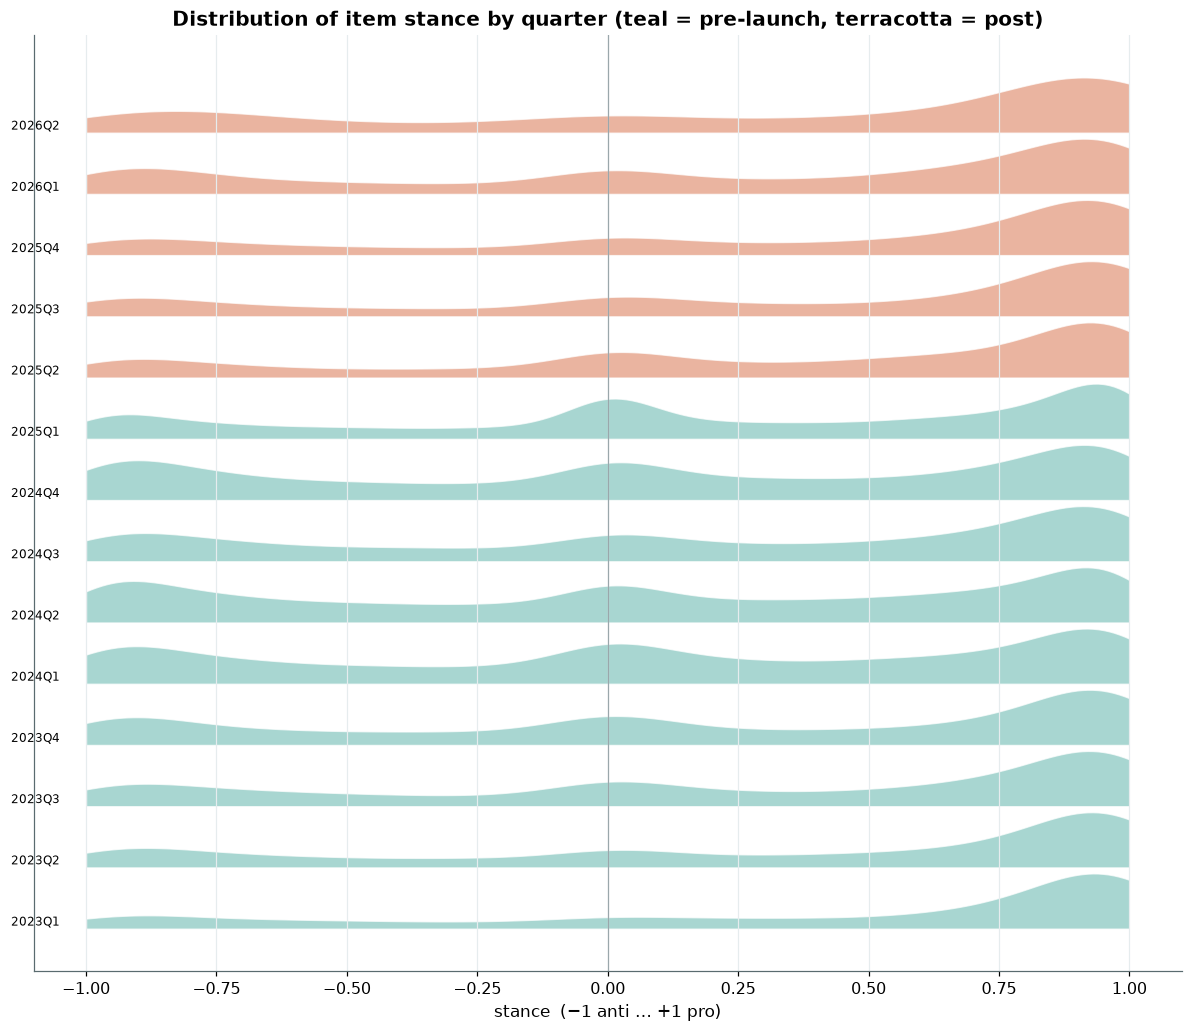

In [3]:
items["q"] = items.et_date.dt.to_period("Q")
qs = [q for q in sorted(items.q.unique())]
fig, ax = plt.subplots(figsize=(11, 0.5*len(qs)+2))
xs = np.linspace(-1,1,200)
from scipy.stats import gaussian_kde
for i,q in enumerate(qs):
    v = items.loc[items.q==q,"s"].dropna()
    if len(v) < 30: continue
    kde = gaussian_kde(v); ys = kde(xs); ys = ys/ys.max()*0.9
    base = i
    pre_launch = q.start_time < pd.Timestamp("2025-01-05")
    col = C.PALETTE["teal"] if pre_launch else C.PALETTE["terracotta"]
    ax.fill_between(xs, base, base+ys, color=col, alpha=0.7, lw=0.8, edgecolor="white")
    ax.text(-1.05, base, str(q), ha="right", va="bottom", fontsize=8)
ax.axvline(0, color="#9AA7AB", lw=0.8)
ax.set_yticks([]); ax.set_xlabel("stance  (−1 anti … +1 pro)")
ax.set_title("Distribution of item stance by quarter (teal = pre-launch, terracotta = post)")
plt.tight_layout(); plt.show()

### Mean intensity, entropy & bimodality over time

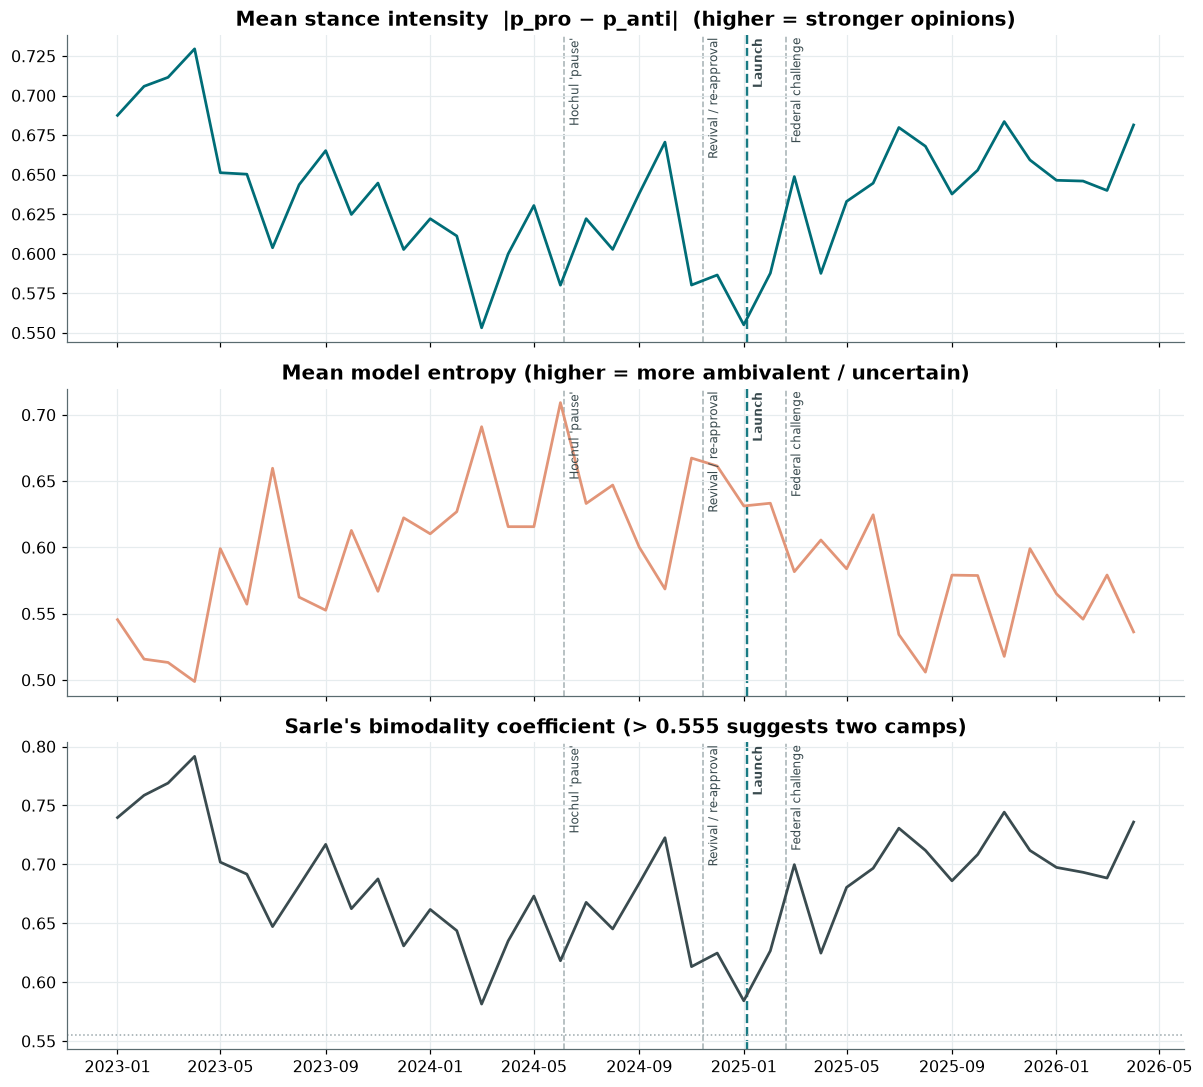

In [4]:
from scipy.stats import skew, kurtosis
def bimodality(x):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    if len(x) < 8: return np.nan
    g = skew(x); k = kurtosis(x, fisher=True)
    return (g**2 + 1) / (k + 3*(len(x)-1)**2/((len(x)-2)*(len(x)-3)))   # Sarle's BC

prof = items.groupby("period").agg(
    intensity=("s", lambda v: np.nanmean(np.abs(v))),
    mean_s=("s","mean"),
    entropy=("entropy","mean"),
    n=("s","size"))
prof["bimodality"] = items.groupby("period")["s"].apply(bimodality)
prof = prof[prof.n >= C.MIN_N]

fig, axes = plt.subplots(3,1, figsize=(11,10), sharex=True)
axes[0].plot(prof.index, prof.intensity, color=C.PALETTE["deep_teal"], lw=1.8); axes[0].set_title("Mean stance intensity  |p_pro − p_anti|  (higher = stronger opinions)")
axes[1].plot(prof.index, prof.entropy, color=C.PALETTE["terracotta"], lw=1.8); axes[1].set_title("Mean model entropy (higher = more ambivalent / uncertain)")
axes[2].plot(prof.index, prof.bimodality, color="#3A4B4F", lw=1.8); axes[2].axhline(0.555, color="#9AA7AB", ls=":", lw=1); axes[2].set_title("Sarle's bimodality coefficient (> 0.555 suggests two camps)")
for ax in axes: A.annotate_events(ax)
plt.tight_layout(); plt.show()

### Pre vs post launch — did the distribution shift? (KS test)

A two-sample Kolmogorov–Smirnov test on the per-item stance distribution before
vs after launch. Significant = the *shape* changed, not just the mean.

pre  n=28,490  mean=+0.120  intensity=0.597
post n=46,904  mean=+0.223  intensity=0.590
KS statistic=0.0763  p=2.89e-90


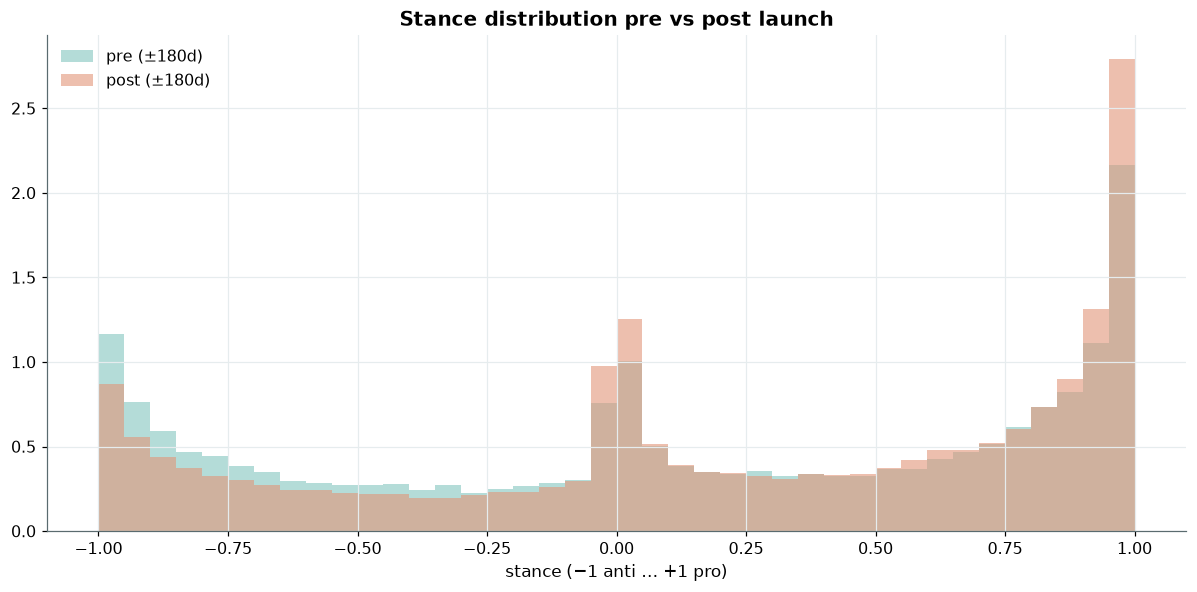

In [5]:
from scipy.stats import ks_2samp
launch = pd.Timestamp("2025-01-05")
pre  = items.loc[(items.et_date>=launch-pd.Timedelta(days=180))&(items.et_date<launch),"s"].dropna()
post = items.loc[(items.et_date>=launch)&(items.et_date<launch+pd.Timedelta(days=180)),"s"].dropna()
ks = ks_2samp(pre, post)
print(f"pre  n={len(pre):,}  mean={pre.mean():+.3f}  intensity={np.abs(pre).mean():.3f}")
print(f"post n={len(post):,}  mean={post.mean():+.3f}  intensity={np.abs(post).mean():.3f}")
print(f"KS statistic={ks.statistic:.4f}  p={ks.pvalue:.3g}")
fig, ax = plt.subplots()
ax.hist(pre, bins=40, range=(-1,1), density=True, alpha=0.6, color=C.PALETTE["teal"], label="pre (±180d)")
ax.hist(post, bins=40, range=(-1,1), density=True, alpha=0.6, color=C.PALETTE["terracotta"], label="post (±180d)")
ax.set_xlabel("stance (−1 anti … +1 pro)"); ax.set_title("Stance distribution pre vs post launch"); ax.legend()
plt.tight_layout(); plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a322346-8e1e-4650-8cef-fe9b767d96fb' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>